<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-26-principal-component-analysis-pca?scriptVersionId=341498889" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🤖 ML 26 — Principal Component Analysis (PCA)

### **Understanding Dimensionality Reduction with PCA**

---

# Introduction

## What is PCA?

**Principal Component Analysis (PCA)** is an **unsupervised dimensionality-reduction technique** used to transform a dataset with many features into a smaller number of new features called **principal components**.

PCA tries to:

* 📉 Reduce the number of features
* 📊 Preserve as much information/variance as possible
* 🚀 Make ML models faster
* 🧹 Remove redundant information
* 👁️ Help visualize high-dimensional data

## Simple Example

Suppose we have:

```text
Feature 1 ─┐
Feature 2 ─┤
           ├──► PCA ───► Principal Component 1
Feature 3 ─┤
Feature 4 ─┘
```

Instead of working with 4 original features, PCA might represent the same dataset using only **1 principal components**.



---

# Why Do We Need PCA?

Imagine a dataset with **100 features**.

Some features might be:

* highly correlated
* redundant
* noisy
* difficult to visualize

For example:

```text
Height
Weight
BMI
Waist Size
```

These features contain overlapping information.

PCA can combine this information into fewer dimensions:

```text
Height
Weight
BMI
Waist Size
      ↓
     PCA
      ↓
PC1
PC2
```

So instead of feeding 100 features into a model, we might use only 10 principal components.



---

# What is Dimensionality Reduction?

**Dimensionality reduction** means reducing the number of features while trying to preserve the important information in the data.

There are two major approaches:

## Feature Selection

Select existing features.

```text
X1 X2 X3 X4 X5
 ↓     ↓     ↓
X1    X3    X5
```

## Feature Extraction

Create new features from existing features.

```text
X1 X2 X3 X4 X5
       ↓
      PCA
       ↓
     PC1 PC2
```

**PCA is a feature extraction technique.**



---

# PCA Intuition

The main idea behind PCA is:

> Find new directions in the data that capture the maximum amount of variance.

Consider data distributed like this:

```text
        •
      •
    •
  •
•
```

There is a direction along which the data varies the most.

PCA finds that direction and calls it:

**Principal Component 1 (PC1)**

Then PCA finds another direction perpendicular to PC1 that captures the next highest amount of variance:

**Principal Component 2 (PC2)**

---

# Principal Components

Principal components are **new features created by PCA**.

They are linear combinations of the original features.

For example:

$PC_1 = 0.7X_1 + 0.5X_2 + 0.4X_3$

$PC_2 = -0.3X_1 + 0.8X_2 - 0.2X_3$

The important thing is that:

* PC1 captures the maximum variance
* PC2 captures the next highest variance
* PC3 captures the next highest variance
* and so on

Each principal component is **orthogonal** to the others.



---

# Variance in PCA

Variance tells us how spread out the data is.

PCA assumes that directions with higher variance contain more useful information.

For example:

```text
Low variance              High variance

••••                      •
••••                    •
••••                  •
••••                •
                       •
```

PCA searches for directions with maximum variance.

---

# How PCA Works

PCA can be understood through these major steps:

```text
Original Dataset
       ↓
Standardize Features
       ↓
Calculate Covariance Matrix
       ↓
Calculate Eigenvalues & Eigenvectors
       ↓
Rank Components
       ↓
Select Top Components
       ↓
Transform Dataset
       ↓
Reduced Dataset
```

Let's understand each step.




---
# Creating a Synthetic Dataset

Generating two classes of 3-feature data from normal distributions and combine them into a single dataset

In [1]:
import numpy as np
import pandas as pd

np.random.seed(23)

class1 = np.random.randn(20, 3)
class2 = np.random.randn(20, 3) + 1

df = pd.DataFrame(
    np.vstack([class1, class2]),
    columns=['feature1', 'feature2', 'feature3']
)

df['target'] = [1] * 20 + [0] * 20

df = df.sample(frac=1, random_state=23).reset_index(drop=True)

df.head()

,feature1,feature2,feature3,target
0,-0.331617,-1.632386,0.619114,1
1,1.010229,1.437830,2.327788,0
2,0.241106,-0.952510,-0.136267,1
3,1.676860,4.187503,-0.080565,0
4,2.823378,-0.332863,2.637391,0


In [2]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

---
# Step 1 — Standardization

Before applying PCA, features should generally be standardized.

Why?

Suppose:

```text
Age        → 18-80
Income     → 20,000-500,000
```

Income has much larger numerical values.

Without scaling, it could dominate the PCA calculation.

We can standardize using:


$z = \frac{x-\mu}{\sigma}$


In Scikit-learn:


In [3]:
# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

---

# Step 2 — Covariance Matrix

PCA analyzes how features vary together.

The **covariance matrix** represents relationships between features.

For two features:

$Cov(X,Y)$

Positive covariance means they tend to increase together.

Negative covariance means one tends to increase when the other decreases.



In [4]:
covariance_matrix = np.cov([df.feature1, df.feature2, df.feature3])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.34076734 0.24528825 0.10420627]
 [0.24528825 1.12566959 0.23643388]
 [0.10420627 0.23643388 1.327287  ]]


---

# Step 3 — Eigenvalues & Eigenvectors

This is the mathematical heart of PCA.

PCA calculates:

* **Eigenvectors** → directions of the principal components
* **Eigenvalues** → amount of variance captured by those directions

Think of it like:

```text
Eigenvector → Direction
Eigenvalue  → Importance of that direction
```

If:

```text
Eigenvalues:

PC1 → 5.8
PC2 → 2.1
PC3 → 0.7
PC4 → 0.2
```

PC1 contains the most variance.

So:

```text
PC1 > PC2 > PC3 > PC4
```

in terms of explained variance.



In [5]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [6]:
eigen_values

array([1.65691289, 1.22963722, 0.90717381])

In [7]:
eigen_vectors

array([[-0.61002583, -0.69239396,  0.3853039 ],
       [-0.53982115,  0.00718615, -0.84174906],
       [-0.58005311,  0.72148387,  0.37815264]])

---
# Step 4 — Visualize Eigenvectors in 3D

Ploting our 3-dimensional dataset and visualize its mean point and eigenvectors. The eigenvectors show the important directions along which the data varies, which are used by PCA to find the principal components.

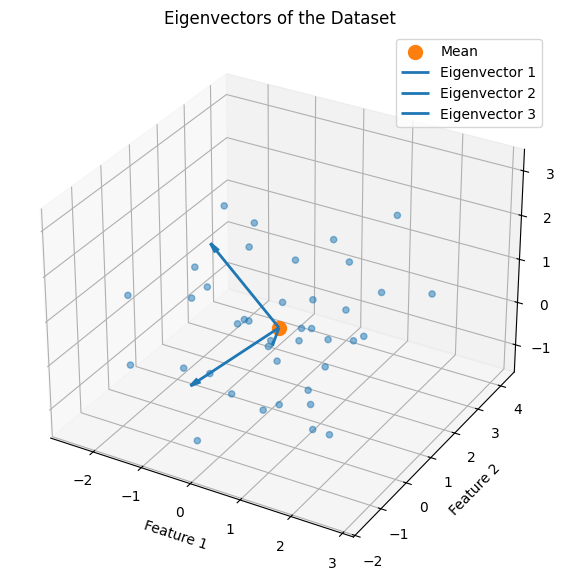

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Mean of the data
mean = df[['feature1', 'feature2', 'feature3']].mean().values

# Eigenvectors
eigen_vectors = eigen_vectors.T

# Create 3D plot
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot data points
ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    alpha=0.5
)

# Plot mean
ax.scatter(
    *mean,
    s=100,
    label='Mean'
)

# Plot eigenvectors
for i, v in enumerate(eigen_vectors):
    ax.quiver(
        *mean,
        *v,
        length=2,
        arrow_length_ratio=0.1,
        linewidth=2,
        label=f'Eigenvector {i+1}'
    )

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')

ax.set_title('Eigenvectors of the Dataset')
ax.legend()

plt.show()

---

# Step 5 — Select Components

Suppose we start with:

```text
50 features
```

After PCA:

```text
PC1
PC2
PC3
PC4
PC5
```

We might keep only:

```text
PC1 + PC2 + PC3 + PC4 + PC5
```

Now the dataset has only **5 features instead of 50**.


In [9]:
pc = eigen_vectors[0:2]
pc

array([[-0.61002583, -0.53982115, -0.58005311],
       [-0.69239396,  0.00718615,  0.72148387]])

In [10]:
transformed_df = np.dot(X_scaled, pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,1.511668,0.418323,1
1,-1.657529,0.710462,0
2,1.240937,-0.402925,1
3,-2.202040,-1.201809,0
4,-1.870388,-0.203340,0


In [11]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()